In [20]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted


In [21]:
import os
os.chdir('/content/drive/MyDrive/Project2DL/quadwaterfall')

# Verify files exist
required_files = ['architecture.py', 'dataset.py', 'config.py', 'train.py', 'hyperparameter_search.py']
for f in required_files:
    assert os.path.exists(f), f"Missing {f}"
print("✅ All files found")

# Install dependencies
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q timm pillow numpy optuna tqdm
print("✅ Dependencies installed")

✅ All files found
✅ Dependencies installed


In [17]:
# Check dataset
dataset_path = '../multimodal_dataset'
assert os.path.exists(dataset_path), f"Dataset not found at {dataset_path}"

# Verify structure
required_dirs = ['polL_color', 'polL_aolp_cos', 'polL_aolp_sin', 'polL_dolp',
                 'NIR_warped', 'NIR_warped_mask', 'SSGT4MS', 'list_folder']
for d in required_dirs:
    path = f'{dataset_path}/{d}'
    assert os.path.exists(path), f"Missing {d}"
    print(f"✅ {d}")

# Count samples
train_count = len(open(f'{dataset_path}/list_folder/train.txt').readlines())
val_count = len(open(f'{dataset_path}/list_folder/val.txt').readlines())
test_count = len(open(f'{dataset_path}/list_folder/test.txt').readlines())

print(f"\n✅ Dataset verified:")
print(f"   Train: {train_count} samples")
print(f"   Val:   {val_count} samples")
print(f"   Test:  {test_count} samples")

✅ polL_color
✅ polL_aolp_cos
✅ polL_aolp_sin
✅ polL_dolp
✅ NIR_warped
✅ NIR_warped_mask
✅ SSGT4MS
✅ list_folder

✅ Dataset verified:
   Train: 302 samples
   Val:   96 samples
   Test:  102 samples


In [9]:
!python test_integration.py


QUADWATERFALL INTEGRATION TEST

TEST 1: Model Forward Pass
Input shapes:
  RGB:  (2, 3, 512, 512)
  AoLP: (2, 1, 512, 512)
  DoLP: (2, 1, 512, 512)
  NIR:  (2, 1, 512, 512)

Output shape: (2, 20, 512, 512)
Expected:     (2, 20, 512, 512)

✅ Model forward pass: PASSED

TEST 2: Dataset Loading
Dataset loaded successfully
  Split: train
  Samples: 302
  Crop size: 512×512

Sample keys: ['rgb', 'aolp', 'dolp', 'nir', 'label', 'name']
  rgb:   (3, 512, 512)
  aolp:  (1, 512, 512)
  dolp:  (1, 512, 512)
  nir:   (1, 512, 512)
  label: (512, 512)

Value ranges:
  rgb:   [-2.067, 2.623]
  aolp:  [0.004, 0.991]
  dolp:  [0.000, 1.000]
  nir:   [-1.417, -1.417]
  label: [0, 9]

✅ Dataset loading: PASSED

TEST 3: Training Step (Synthetic Data)
Device: cuda

Training step:
  Batch size: 2
  Resolution: 512×512
  Device: cuda

  • Forward pass... ✓ output shape: (2, 20, 512, 512)
  • Loss computation... ✓ loss: 3.0695
  • Backward pass... ✓
  • Optimizer step... ✓

✅ Training step: PASSED

TEST 4:

In [10]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

    # Test GPU
    x = torch.randn(2, 3, 512, 512).cuda()
    print(f"✅ GPU working (test tensor shape: {x.shape})")
else:
    print("⚠️  No GPU available. Change runtime to GPU in Runtime > Change runtime type")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
GPU Memory: 85.1 GB
✅ GPU working (test tensor shape: torch.Size([2, 3, 512, 512]))


## Train - Test (50 epochs - paper parameters)

In [ ]:
# Default config
!python train.py --batch-size 8 --num-epochs 50 --device cuda

model.safetensors: 100% 250M/250M [00:20<00:00, 12.2MB/s]
model.safetensors: 100% 101M/101M [00:01<00:00, 63.0MB/s]
Starting training for 50 epochs...
Warmup: 10 epochs
LR: 6e-07 → 6e-06 → 1e-09
Poly power: 0.9

Epoch 1/50 | Batch 10/37 | Loss: 3.0021
Epoch 1/50 | Batch 20/37 | Loss: 2.9596
Epoch 1/50 | Batch 30/37 | Loss: 2.7917

Epoch 1 Train Metrics:
  Loss: 2.9316
  mIoU: 0.0189
  mAccuracy: 0.0326
  allAccuracy: 0.1008

Epoch 1 Val Metrics:
  Loss: 2.9701
  mIoU: 0.0083
  mAccuracy: 0.0101
  allAccuracy: 0.0454

Best model saved: checkpoints/best_model.pt
Epoch 2/50 | Batch 10/37 | Loss: 2.7842
Epoch 2/50 | Batch 20/37 | Loss: 2.7126
Epoch 2/50 | Batch 30/37 | Loss: 2.7575

Epoch 2 Train Metrics:
  Loss: 2.7614
  mIoU: 0.0377
  mAccuracy: 0.0540
  allAccuracy: 0.2165

Epoch 2 Val Metrics:
  Loss: 2.7866
  mIoU: 0.0307
  mAccuracy: 0.0371
  allAccuracy: 0.1881

Best model saved: checkpoints/best_model.pt
Epoch 3/50 | Batch 10/37 | Loss: 2.7314
Epoch 3/50 | Batch 20/37 | Loss: 2.711

In [7]:
import json
%matplotlib inline
import matplotlib.pyplot as plt

with open('/tmp/training_history.json') as f:
    history = json.load(f)

epochs = list(range(1, len(history['train_loss']) + 1))
print(f'Loaded history for {len(epochs)} epochs')

Loaded history for 50 epochs


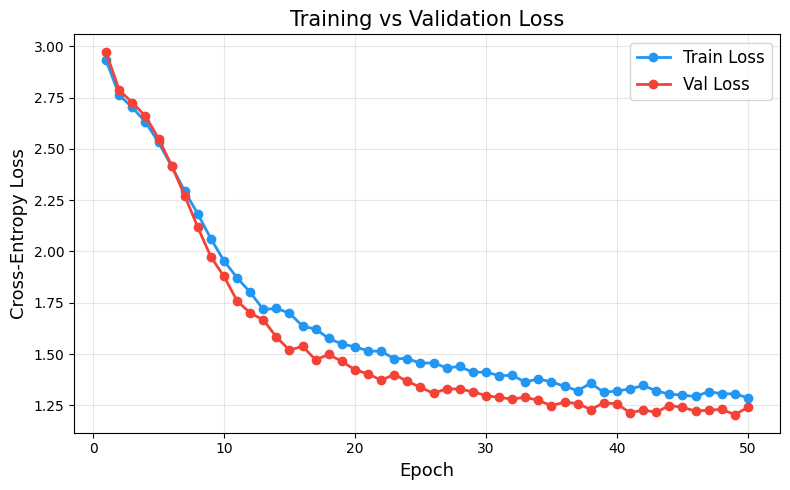

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, history['train_loss'], color='#2196F3', linewidth=2, marker='o', label='Train Loss')
ax.plot(epochs, history['val_loss'],   color='#F44336', linewidth=2, marker='o', label='Val Loss')
ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('Cross-Entropy Loss', fontsize=13)
ax.set_title('Training vs Validation Loss', fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close(fig)

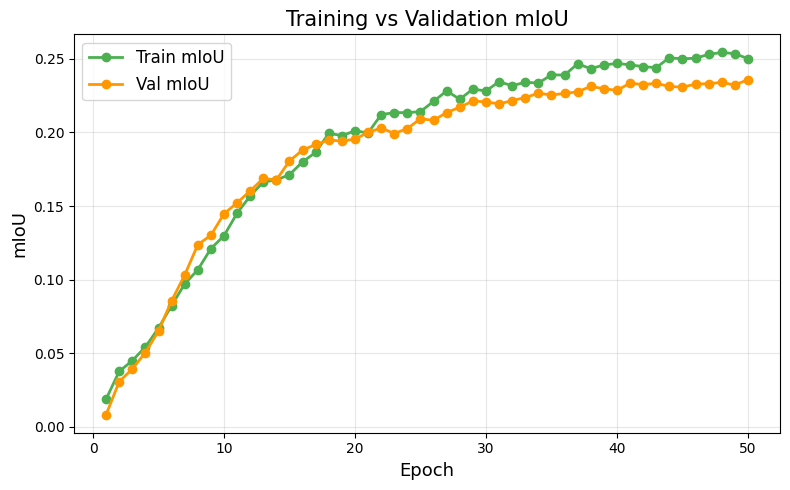

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, history['train_miou'], color='#4CAF50', linewidth=2, marker='o', label='Train mIoU')
ax.plot(epochs, history['val_miou'],   color='#FF9800', linewidth=2, marker='o', label='Val mIoU')
ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('mIoU', fontsize=13)
ax.set_title('Training vs Validation mIoU', fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close(fig)

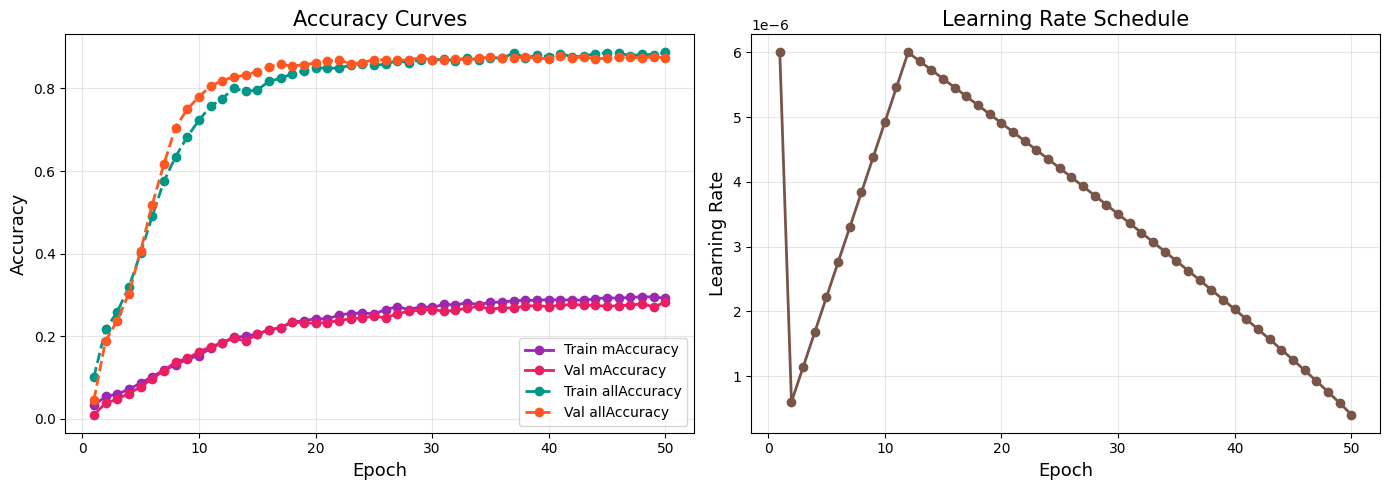

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history['train_macc'],   color='#9C27B0', linewidth=2, marker='o', label='Train mAccuracy')
axes[0].plot(epochs, history['val_macc'],     color='#E91E63', linewidth=2, marker='o', label='Val mAccuracy')
axes[0].plot(epochs, history['train_allacc'], color='#009688', linewidth=2, marker='o', linestyle='--', label='Train allAccuracy')
axes[0].plot(epochs, history['val_allacc'],   color='#FF5722', linewidth=2, marker='o', linestyle='--', label='Val allAccuracy')
axes[0].set_xlabel('Epoch', fontsize=13)
axes[0].set_ylabel('Accuracy', fontsize=13)
axes[0].set_title('Accuracy Curves', fontsize=15)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['lr'], color='#795548', linewidth=2, marker='o')
axes[1].set_xlabel('Epoch', fontsize=13)
axes[1].set_ylabel('Learning Rate', fontsize=13)
axes[1].set_title('Learning Rate Schedule', fontsize=15)
axes[1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)

## Hyperparameter Search for 7 parameters

#### Key Parameters Searched

| Parameter | Paper Value | Search Range |
|-----------|------------|--------------|
| `lr_max` | 6e-6 | [2e-6, 1.5e-5] |
| `lr_init` | 6e-7 | [2e-7, 1.5e-6] |
| `lr_min` | 1e-9 | [1e-10, 1e-8] |
| `weight_decay` | 1e-2 | [5e-3, 3e-2] |
| `warmup_epochs` | 10 | [2, 15] |
| `poly_power` | 0.9 | [0.7, 1.0] |
| `dropout_p` | 0.1 | [0.05, 0.3] |

In [6]:
import sys
import os

# Add current dir to path so imports work
sys.path.insert(0, os.getcwd())

# Set command-line arguments
sys.argv = [
    "hyperparameter_search.py",
    "--n-trials", "12",
    "--epochs-per-trial", "15",
    "--batch-size", "8",
    "--skip-full-train",
]

# Import and run directly
from hyperparameter_search import main

print("Starting search...\n")
main()

Starting search...


  Bayesian Hyperparameter Search — QuadWaterfall Semantic Segmentation
  Trials:           12
  Epochs per trial: 15
  Batch size:       8
  Device:           cuda
  Data root:        ../multimodal_dataset
  Results dir:      optuna_results
  Database:         optuna_results/quadwaterfall_study.db
  Metric:           mIoU (maximize)



[I 2026-04-28 14:35:50,565] A new study created in RDB with name: quadwaterfall_hyperparameter_search


  0%|          | 0/12 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
Trial 0:   0%|                                                               | 0/15 [00:00<?, ?it/s]

Epoch 1/15 | Batch 10/37 | Loss: 2.9445
Epoch 1/15 | Batch 20/37 | Loss: 2.8893
Epoch 1/15 | Batch 30/37 | Loss: 2.7801


...


Epoch 3 Train Metrics:
  Loss: 2.4109
  mIoU: 0.0901
  mAccuracy: 0.1073
  allAccuracy: 0.5149

Epoch 3 Val Metrics:
  Loss: 2.3760
  mIoU: 0.0974
  mAccuracy: 0.1136
  allAccuracy: 0.5661


  Trial 11 | Epoch 3/15 | Val mIoU: 0.0974 | LR: 2.55e-06


Trial 11:  20%|████████▏                                | 3/15 [04:58<17:51, 89.33s/it, mIoU=0.0974]


  ⚠️  Trial 11 PRUNED at epoch 3 (mIoU=0.0974)


Trial 11:  20%|████████▏                                | 3/15 [04:58<19:53, 99.45s/it, mIoU=0.0974]


[I 2026-04-28 17:20:55,541] Trial 11 pruned. 

  Search Complete!
  Total time:        2.75 hours
  Trials completed:  12
  Trials pruned:     7
  Best mIoU:         0.1978
  Best trial:        3

  Best hyperparameters:
    lr_max              : 0.000014
    lr_init             : 0.000001
    lr_min              : 0.000000
    weight_decay        : 0.005164
    warmup_epochs       : 15
    poly_power          : 0.972299
    dropout_p           : 0.079453

  ✓ Best params saved to: optuna_results/best_params.json
  ✓ All trials saved to: optuna_results/all_trials.json

  Skipping full training (--skip-full-train).
  To train manually with best params, create train.py args or modify config.py:

  Key parameters to use:
    lr_max: 0.000014
    lr_init: 0.000001
    lr_min: 0.000000
    weight_decay: 0.005164
    warmup_epochs: 15
    poly_power: 0.972299
    dropout_p: 0.079453




### Trials

Trial 0: Complete
- lr_max: 4.25e-06
- lr_min: 2.91e-09
- lr_init: 1.36e-06
- weight_decay: 0.01462
- warmup_epochs: 4
- poly_power: 0.747
- dropout_p: 0.0645

Trial 1: Complete
- dropout_p: 1.030848e-01
- lr_init: 6.714945e-07
- lr_max: 1.145479e-05
- lr_min: 2.607025e-09
- warmup_epochs: 15
- poly_power: 9.497328e-01
- weight_decay: 5.187855e-03

Trial 2: Complete
- dropout_p: 2.029632e-01
- lr_init: 2.894144e-07
- lr_max: 2.884948e-06
- lr_min: 4.059612e-10
- warump_epochs: 8
- poly_power: 7.873687e-01
- weight_decay: 1.280294e-02

Trial 3: Complete
- dropout_p: 7.945338e-02
- lr_init: 7.490094e-07
- lr_max: 1.437406e-05
- lr_min: 8.691089e-09
- warmup_epochs: 15
- poly_power: 9.722994e-01
- weight_decay: 5.163534e-03

Trial 4: Complete
- dropout_p: 2.782678e-01
- lr_init: 7.072803e-07
- lr_max: 1.431595e-05
- lr_min: 9.654401e-09
- poly_power: 9.774199e-01
- warmup_epochs: 15
- weight_decay: 5.247818e-03

Trial 5: Pruned
- dropout_p: 1.415393e-01
- lr_init: 1.317358e-06
- lr_max: 7.794519e-06
- lr_min: 1.424657e-10
- poly_power: 8.915161e-01
- warmup_epochs: 10
- weight_decay: 2.923489e-02

Trial 6: Pruned
- dropout_p: 5.826762e-02
- lr_init: 3.240656e-07
- lr_max: 5.792538e-06
- lr_min: 6.641919e-09
- poly_power: 8.551004e-01
- warmup_epochs: 10
- weight_decay: 7.304619e-03

Trial 7: Pruned
- dropout_p: 1.879163e-01
- lr_init: 5.018032e-07
- lr_max: 9.353232e-06
- lr_min: 7.520736e-10
- poly_power: 9.989382e-01
- warmup_epochs: 2
- weight_decay: 8.837516e-03

Trial 8: Pruned
 - dropout_p: 2.501796e-01
 - lr_init: 8.703224e-07
- lr_max: 2.482157e-06
- lr_min: 2.036844e-09
- poly_power: 9.120898e-01
- warmup_epochs: 12.000000
- weight_decay: 2.107017e-02

Trial 9: Pruned
- dropout_p: 1.182129e-01
- lr_init: 4.344107e-07
- lr_max: 6.166134e-06
- lr_min: 2.458249e-10
- poly_power: 8.034125e-01
- warmup_epochs: 6
- weight_decay: 8.382080e-03

Trial 10: Pruned
- dropout_p: 1.542537e-01
- lr_init: 9.756361e-07
- lr_max: 3.757762e-06
- lr_min: 1.050097e-09
- poly_power: 7.014220e-01
- warmup_epochs: 13
- weight_decay: 1.708749e-02

Trial 11: Pruned
- dropout_p: 9.435711e-02
- lr_init: 6.750486e-07
- lr_max: 1.474083e-05
- lr_min: 3.818839e-09
- poly_power: 9.510918e-01
- warmup_epochs: 15
- weight_decay: 5.108176e-03

## Full-length training on best parameters

In [11]:
# Full training with best parameters from Optuna
!python train.py \
  --batch-size 8 \
  --num-epochs 100 \
  --lr-init 1.0e-06 \
  --lr-max 1.4e-05 \
  --lr-min 8.69e-10 \
  --warmup-epochs 15 \
  --weight-decay 5.164e-03 \
  --poly-power 0.972299 \
  --dropout-p 0.079453 \
  --device cuda

model.safetensors: 100% 250M/250M [00:06<00:00, 41.0MB/s]
model.safetensors: 100% 101M/101M [00:01<00:00, 63.0MB/s]
Starting training for 100 epochs...
Warmup: 15 epochs
LR: 1e-06 → 1.4e-05 → 8.69e-10
Poly power: 0.972299

Epoch 1/100 | Batch 10/37 | Loss: 2.8871
Epoch 1/100 | Batch 20/37 | Loss: 2.7308
Epoch 1/100 | Batch 30/37 | Loss: 2.5636

Epoch 1 Train Metrics:
  Loss: 2.7483
  mIoU: 0.0490
  mAccuracy: 0.0751
  allAccuracy: 0.2553

Epoch 1 Val Metrics:
  Loss: 2.7101
  mIoU: 0.0539
  mAccuracy: 0.0787
  allAccuracy: 0.3078

Best model saved: checkpoints/best_model.pt
Epoch 2/100 | Batch 10/37 | Loss: 2.4557
Epoch 2/100 | Batch 20/37 | Loss: 2.4210
Epoch 2/100 | Batch 30/37 | Loss: 2.4127

Epoch 2 Train Metrics:
  Loss: 2.4487
  mIoU: 0.0978
  mAccuracy: 0.1345
  allAccuracy: 0.5284

Epoch 2 Val Metrics:
  Loss: 2.5484
  mIoU: 0.0777
  mAccuracy: 0.1130
  allAccuracy: 0.4353

Best model saved: checkpoints/best_model.pt
Epoch 3/100 | Batch 10/37 | Loss: 2.4059
Epoch 3/100 | Batch 

: 

In [86]:
import json

with open('/tmp/training_history.json') as f:
    history = json.load(f)

num_epochs = len(history['train_loss'])
best_idx = history['val_miou'].index(max(history['val_miou']))

print("=" * 60)
print("TRAINING COMPLETE - FINAL RESULTS")
print("=" * 60)
print(f"\nTotal epochs trained: {num_epochs}")
print(f"\nFinal metrics (Epoch {num_epochs}):")
print(f"  Train Loss: {history['train_loss'][-1]:.4f}")
print(f"  Val Loss: {history['val_loss'][-1]:.4f}")
print(f"  Train mIoU: {history['train_miou'][-1]:.4f}")
print(f"  Val mIoU: {history['val_miou'][-1]:.4f}")

print(f"\n✓ BEST MODEL:")
print(f"  Epoch: {best_idx + 1}")
print(f"  Val mIoU: {max(history['val_miou']):.4f}")
print(f"  Path: checkpoints/best_model.pt")
print("\n" + "=" * 60)


TRAINING COMPLETE - FINAL RESULTS

Total epochs trained: 96

Final metrics (Epoch 96):
  Train Loss: 0.7323
  Val Loss: 0.7632
  Train mIoU: 0.3142
  Val mIoU: 0.2718

✓ BEST MODEL:
  Epoch: 94
  Val mIoU: 0.2719
  Path: checkpoints/best_model.pt



In [87]:
import json
%matplotlib inline
import matplotlib.pyplot as plt

with open('/tmp/training_history.json') as f:
    history = json.load(f)

epochs = list(range(1, len(history['train_loss']) + 1))
print(f'Loaded history for {len(epochs)} epochs')

Loaded history for 96 epochs


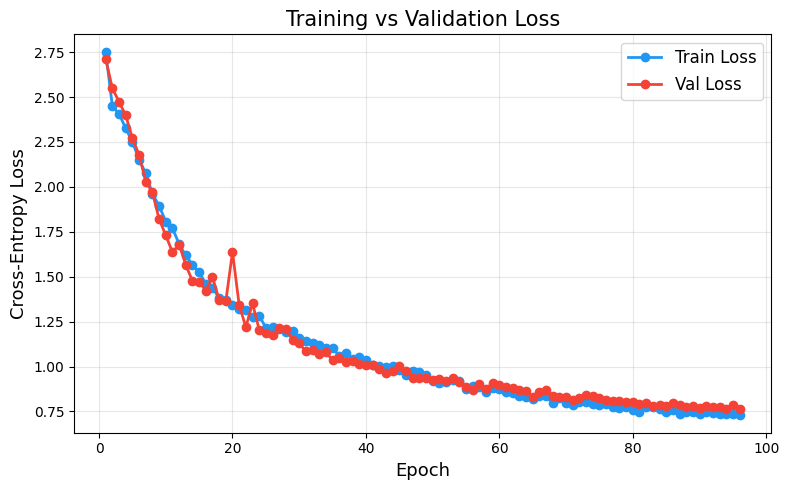

In [88]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, history['train_loss'], color='#2196F3', linewidth=2, marker='o', label='Train Loss')
ax.plot(epochs, history['val_loss'],   color='#F44336', linewidth=2, marker='o', label='Val Loss')
ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('Cross-Entropy Loss', fontsize=13)
ax.set_title('Training vs Validation Loss', fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close(fig)

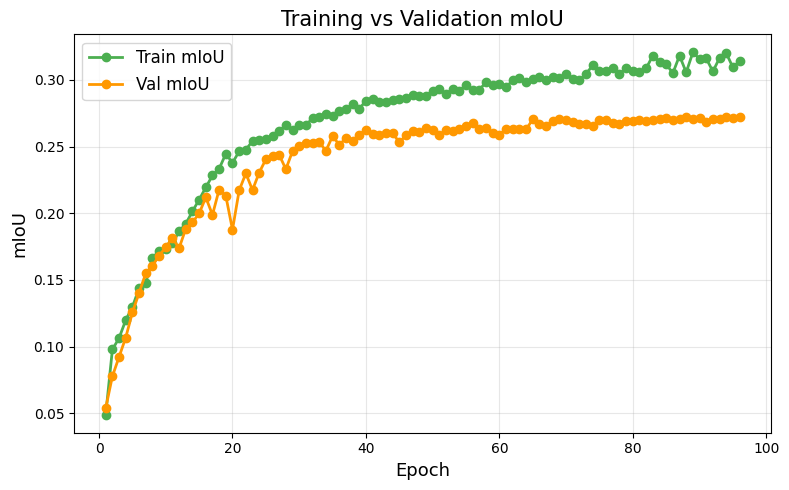

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, history['train_miou'], color='#4CAF50', linewidth=2, marker='o', label='Train mIoU')
ax.plot(epochs, history['val_miou'],   color='#FF9800', linewidth=2, marker='o', label='Val mIoU')
ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('mIoU', fontsize=13)
ax.set_title('Training vs Validation mIoU', fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close(fig)

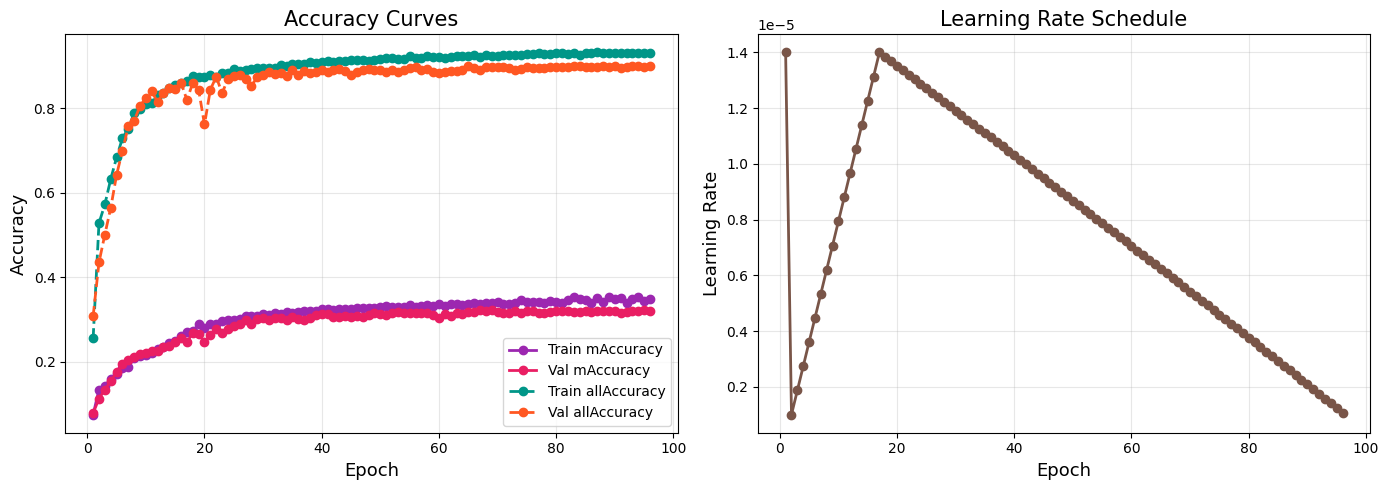

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history['train_macc'],   color='#9C27B0', linewidth=2, marker='o', label='Train mAccuracy')
axes[0].plot(epochs, history['val_macc'],     color='#E91E63', linewidth=2, marker='o', label='Val mAccuracy')
axes[0].plot(epochs, history['train_allacc'], color='#009688', linewidth=2, marker='o', linestyle='--', label='Train allAccuracy')
axes[0].plot(epochs, history['val_allacc'],   color='#FF5722', linewidth=2, marker='o', linestyle='--', label='Val allAccuracy')
axes[0].set_xlabel('Epoch', fontsize=13)
axes[0].set_ylabel('Accuracy', fontsize=13)
axes[0].set_title('Accuracy Curves', fontsize=15)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['lr'], color='#795548', linewidth=2, marker='o')
axes[1].set_xlabel('Epoch', fontsize=13)
axes[1].set_ylabel('Learning Rate', fontsize=13)
axes[1].set_title('Learning Rate Schedule', fontsize=15)
axes[1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)

## Finally, evaluate on test set

In [ ]:
import torch
from quadwaterfall.architecture import QuadWaterfall
from quadwaterfall.train import Trainer, SegmentationMetrics
from quadwaterfall.config import Config
from quadwaterfall.dataset import build_loaders

# Rebuild model with same settings
cfg = Config()
cfg.data.root = "../multimodal_dataset"

model = QuadWaterfall(
    num_classes=20,
    rgb_var='b4',
    aux_var='b2',
    pretrained=False,       # don't re-download pretrained; we load our checkpoint
    p=0.079,
    enc_checkpoint=True,
    qwtm_checkpoint=True,
)

# Load best checkpoint
device = "cuda"
ckpt = torch.load("./checkpoints/best_model.pt", map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(device)
model.eval()

print(f"Loaded epoch {ckpt['epoch']+1}, val mIoU was {ckpt['metrics']['mIoU']:.4f}")

# Run test
_, _, test_loader = build_loaders(cfg.data.root, cfg.data.crop_size, batch_size=1, num_workers=4)
metrics = SegmentationMetrics(num_classes=20, ignore_index=255)

with torch.no_grad():
    for batch in test_loader:
        rgb   = batch["rgb"].to(device)
        aolp  = batch["aolp"].to(device)
        dolp  = batch["dolp"].to(device)
        nir   = batch["nir"].to(device)
        label = batch["label"].to(device)
        pred  = torch.argmax(model(rgb, aolp, dolp, nir), dim=1)
        metrics.update(pred, label)

results = metrics.compute_metrics()
print(f"Test mIoU:      {results['mIoU']:.4f}")
print(f"Test mAccuracy: {results['mAccuracy']:.4f}")
print(f"Test PixAcc:    {results['allAccuracy']:.4f}")